In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv("Downloads/day.csv")

In [4]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


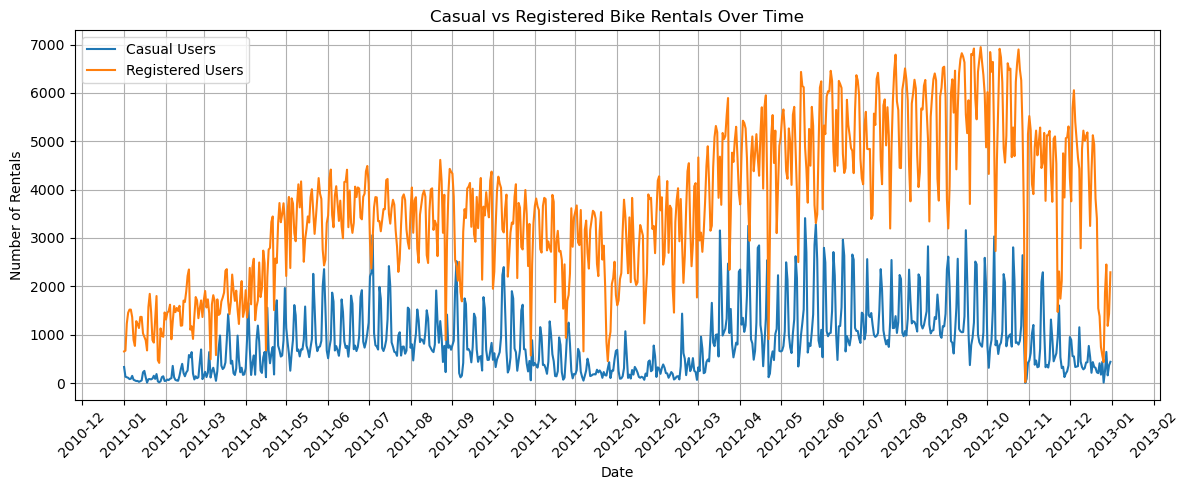

In [29]:
df["dteday"] = pd.to_datetime(df["dteday"])
plt.figure(figsize=(12, 5))

plt.plot(df["dteday"], df["casual"], label="Casual Users")
plt.plot(df["dteday"], df["registered"], label="Registered Users")

plt.title("Casual vs Registered Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Rentals")

# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show(

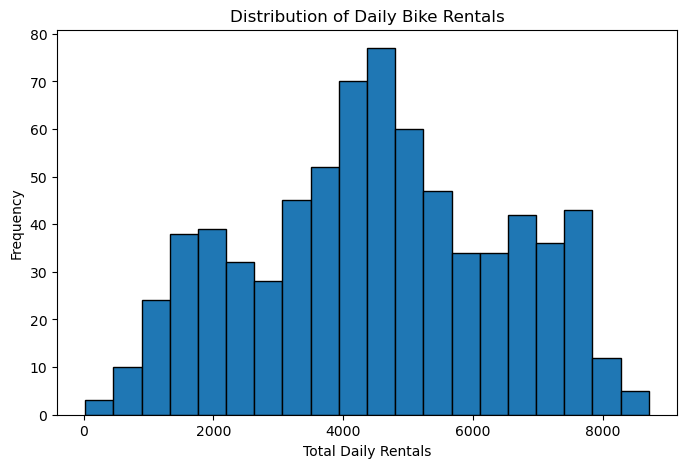

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=20, edgecolor='black')
plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Total Daily Rentals")
plt.ylabel("Frequency")
plt.show()

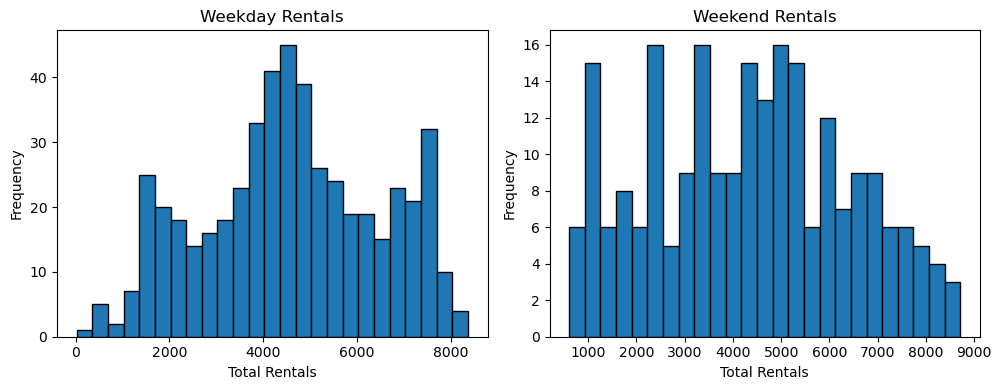

In [33]:
weekday_rentals = df[df["workingday"] == 1]["cnt"]
weekend_rentals = df[df["workingday"] == 0]["cnt"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(weekday_rentals, bins=25 , edgecolor="black")
plt.title("Weekday Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

# Weekends
plt.subplot(1, 2, 2)
plt.hist(weekend_rentals, bins=25, edgecolor="black")
plt.title("Weekend Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

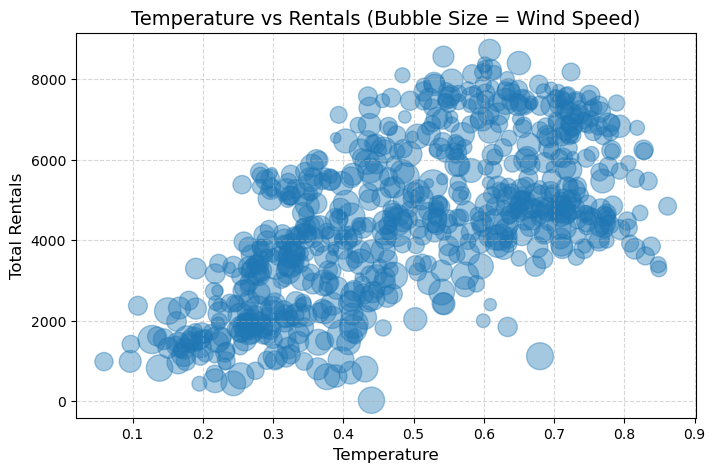

In [35]:
plt.figure(figsize=(8, 5))

bubble_size = df["windspeed"] * 1000

plt.scatter(df["temp"],
            df["cnt"],
            s=bubble_size,
            alpha=0.4)

plt.title("Temperature vs Rentals (Bubble Size = Wind Speed)", fontsize=14)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Total Rentals", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

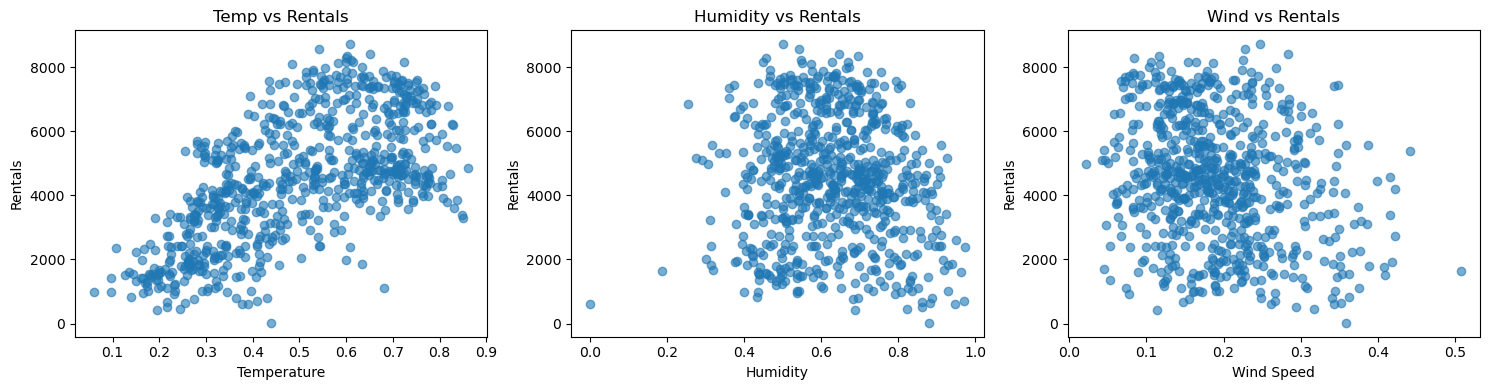

In [43]:
plt.figure(figsize=(15, 4))

# Temperature vs Rentals
plt.subplot(1, 3, 1)
plt.scatter(df["temp"], df["cnt"], alpha=0.6)
plt.title("Temp vs Rentals")
plt.xlabel("Temperature")
plt.ylabel("Rentals")

# Humidity vs Rentals
plt.subplot(1, 3, 2)
plt.scatter(df["hum"], df["cnt"], alpha=0.6)
plt.title("Humidity vs Rentals")
plt.xlabel("Humidity")
plt.ylabel("Rentals")

# Wind Speed vs Rentals
plt.subplot(1, 3, 3)
plt.scatter(df["windspeed"], df["cnt"], alpha=0.6)
plt.title("Wind vs Rentals")
plt.xlabel("Wind Speed")
plt.ylabel("Rentals")

plt.tight_layout()
plt.show()

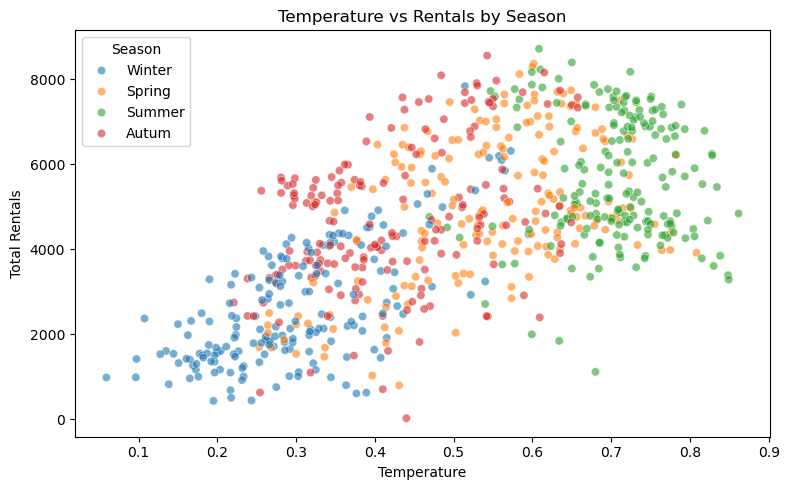

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    hue="Season",
    alpha=0.6
)

plt.title("Temperature vs Rentals by Season")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

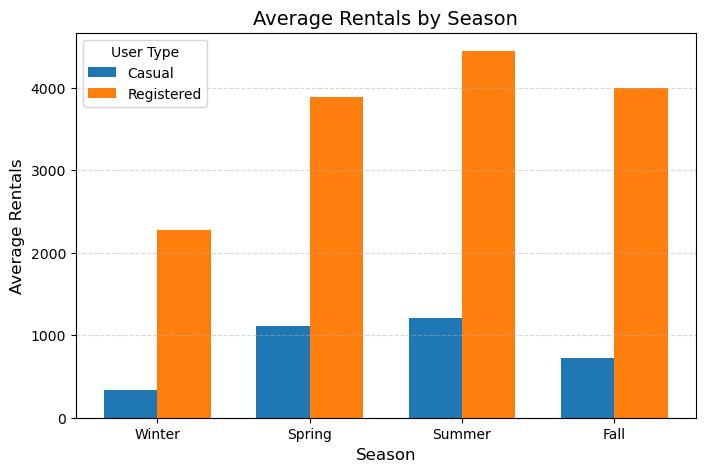

In [36]:

casual_avg = df.groupby("season")["casual"].mean()
registered_avg = df.groupby("season")["registered"].mean()

x = np.arange(len(casual_avg))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, casual_avg.values, width, label="Casual")
plt.bar(x + width/2, registered_avg.values, width, label="Registered")

plt.title("Average Rentals by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)

plt.xticks(x, ["Winter", "Spring", "Summer", "Fall"])  # corrected
plt.legend(title="User Type")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

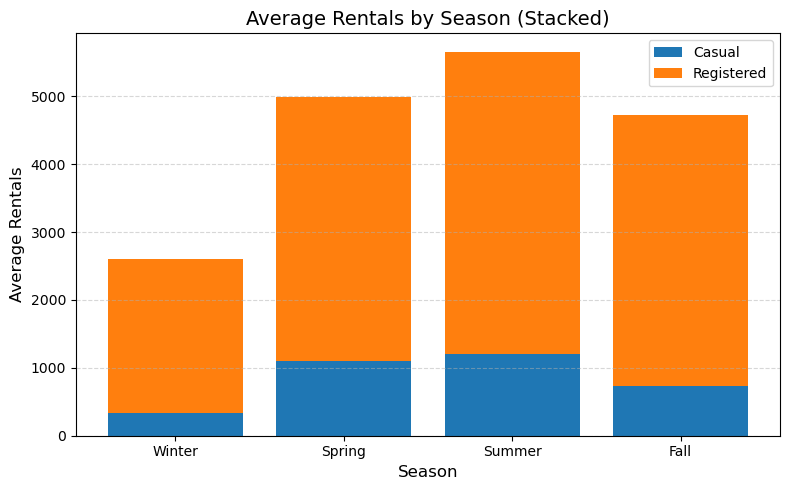

In [5]:
season_avg = df.groupby("season")[["casual", "registered"]].mean()

casual_avg = season_avg["casual"].values
registered_avg = season_avg["registered"].values

x = np.arange(len(season_avg))

plt.figure(figsize=(8, 5))

plt.bar(x, casual_avg, label="Casual")

plt.bar(x, registered_avg, bottom=casual_avg, label="Registered")

plt.title("Average Rentals by Season (Stacked)", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)

plt.xticks(x, ["Winter", "Spring", "Summer", "Fall"])  # fixed order

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
Workingday_map = {0:"No",
                1:"Yes"}
Workingday_map

{0: 'No', 1: 'Yes'}

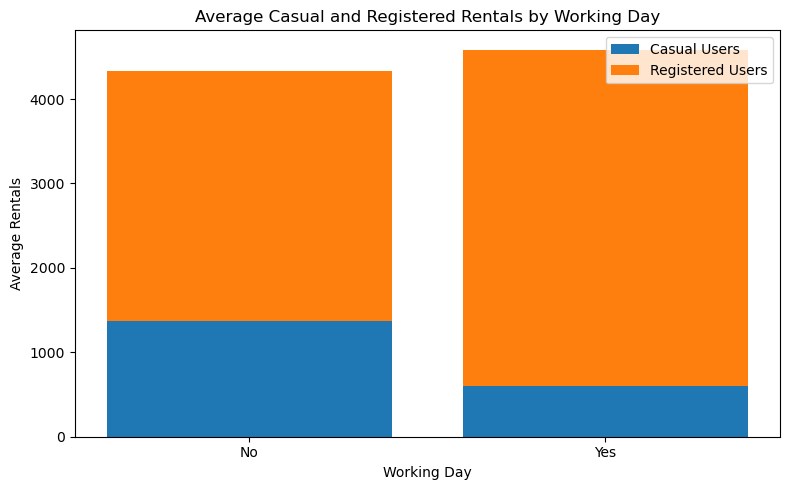

In [39]:
workingday_avg = df.groupby("workingday")[["casual", "registered"]].mean()

casual_avg = workingday_avg["casual"].values
registered_avg = workingday_avg["registered"].values

x = np.arange(len(workingday_avg))

plt.figure(figsize=(8, 5))

plt.bar(x, casual_avg, label="Casual Users")

plt.bar(x, registered_avg, bottom=casual_avg, label="Registered Users")

plt.xticks(x, ["No", "Yes"])

plt.xlabel("Working Day")
plt.ylabel("Average Rentals")
plt.title("Average Casual and Registered Rentals by Working Day")

plt.legend()

plt.tight_layout()
plt.show()

In [40]:
df["Season"] = df["season"].map({
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Autum"
})

df["Working Day"] = df["workingday"].map({
    0: "No",
    1: "Yes"
})


In [41]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,Season,Working Day
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Winter,No
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Winter,No
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Winter,Yes
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Winter,Yes
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Winter,Yes


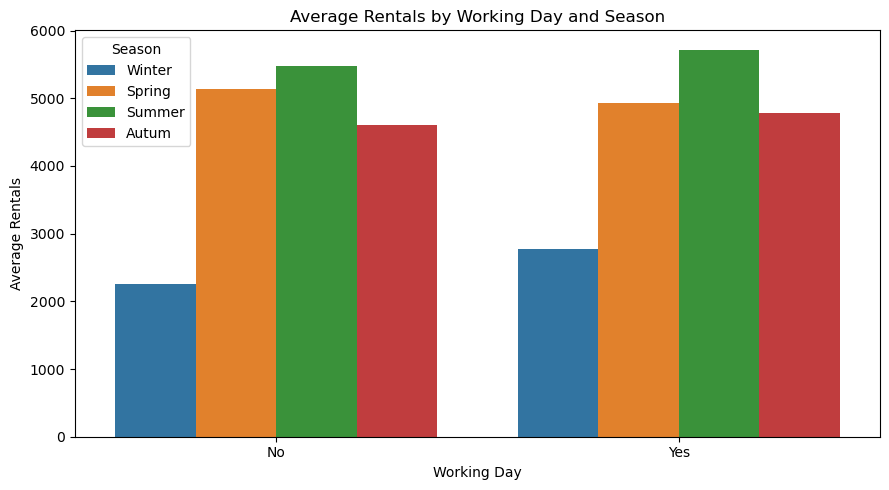

In [42]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Working Day",
    y="cnt",
    hue="Season",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rentals by Working Day and Season")
plt.xlabel("Working Day")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

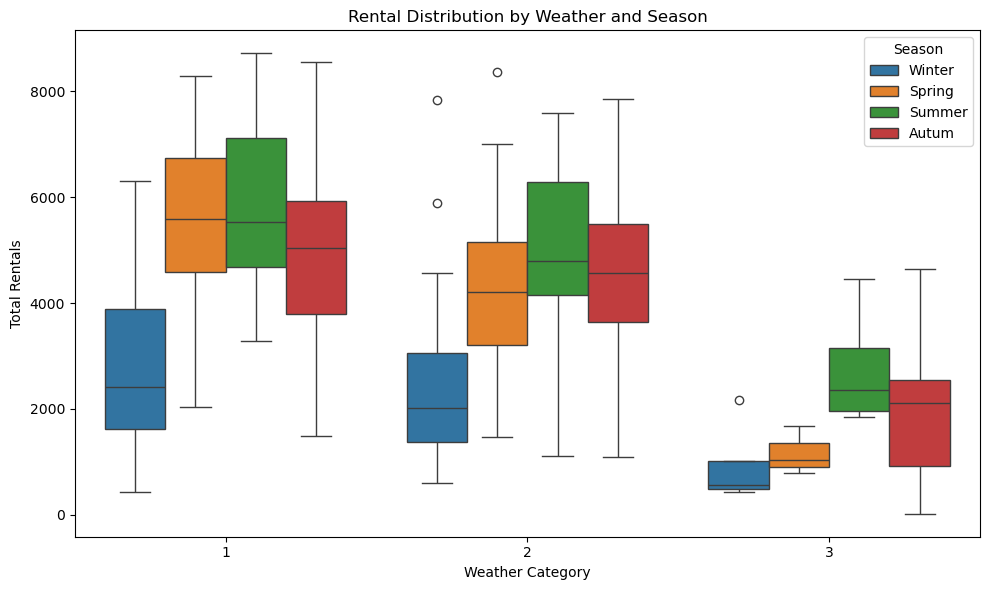

In [44]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="weathersit",
    y="cnt",
    hue="Season"
)

plt.title("Rental Distribution by Weather and Season")
plt.xlabel("Weather Category")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

In [46]:
numeric_df = df[[
    "temp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
]]

corr_matrix = numeric_df.corr()

corr_matrix

,temp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.126963,-0.157944,0.543285,0.540012,0.627494
hum,0.126963,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.543285,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.540012,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.627494,-0.100659,-0.234545,0.672804,0.945517,1.000000


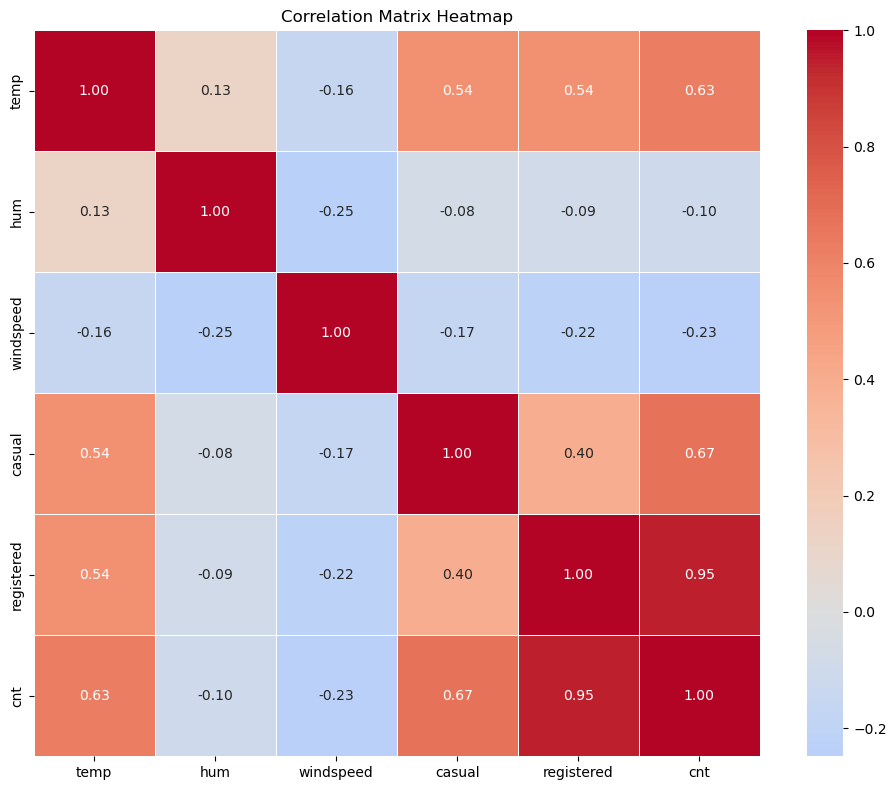

In [47]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

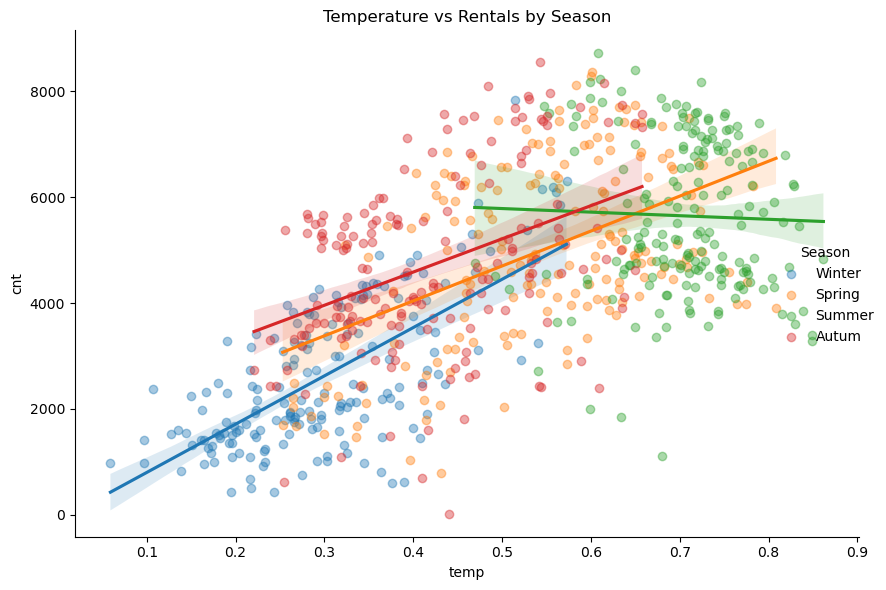

In [48]:
sns.lmplot(
    data=df,
    x="temp",
    y="cnt",
    hue="Season",
    height=6,
    aspect=1.3,
    scatter_kws={"alpha": 0.4}
)

plt.title("Temperature vs Rentals by Season")
plt.tight_layout()
plt.show()

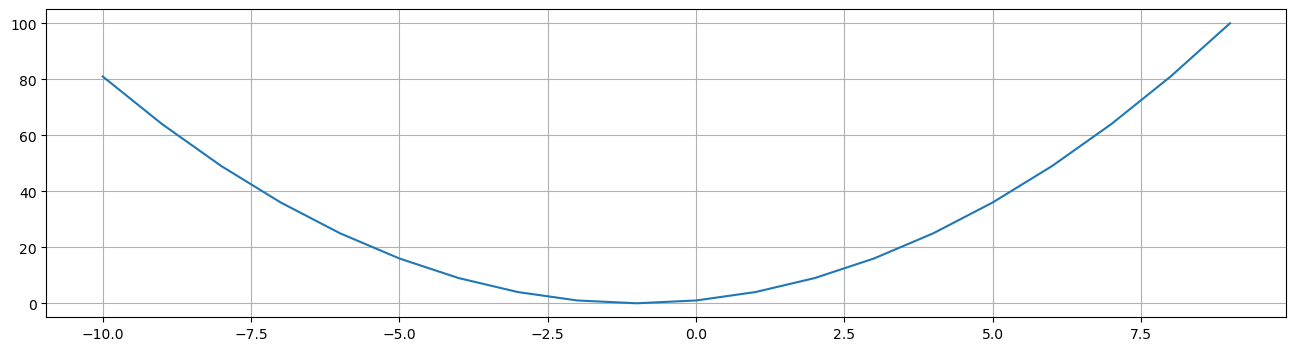

In [49]:
def my_function(x):
    return x ** 2 + 2 * x + 1

x = np.arange(-10, 10)
plt.figure(figsize = (16, 4))
plt.plot(x, my_function(x))
plt.grid(True)